# Chapter 2 — Particles
**Modeling Social Behavior** | Smaldino

---

## What is this model?

This is one of the most foundational agent-based models: **particles doing a random walk in a bounded world**.

Imagine releasing a bunch of gas particles in a closed box. Each particle moves in a direction, randomly wobbles a little each step, and when it gets too close to another particle they "collide" — both scatter off in new random directions. The model counts how many collisions happen over time.

Each particle:
- Has a **position** (x, y) — where it is in the world
- Has a **heading** — the direction it is currently facing (in degrees, 0–360)
- Every tick (time step), it randomly wobbles its heading a little, then moves forward
- If it gets too close to another particle, a **collision** is detected — both get new random headings
- The world **wraps around** (like a torus) — a particle that goes off the right edge reappears on the left

The key scientific question: **how do the parameters affect the collision rate?** More particles = more collisions, obviously. But what about whimsy? Do straight-line movers collide more than random walkers? This is the kind of emergent result ABMs are great at revealing.

---

## Parameters

These are the knobs we can turn to change how the simulation behaves.

| Parameter | What it controls |
|---|---|
| `num_particles` | How many agents exist in the world |
| `whimsy` | Max degrees a particle randomly turns each step. 0 = straight lines, 180 = fully random drunk walk |
| `speed` | How far a particle moves each tick |
| `world_size` | The width and height of the world (it wraps around) |
| `collision_radius` | How close two particles must be to count as a collision |

Notice: `speed` and `whimsy` are **not** properties of individual particles. They are global rules that apply equally to every particle in the simulation. A particle doesn't "have" a speed the way it has a position. Speed is a rule of the world.

---

## Variable types in this model

| Variable type | Who owns it | How long it lives | Examples in this model |
|---|---|---|---|
| **Global** | The whole model | Entire simulation | `collisions`, `tick`, `world_size`, `speed`, `whimsy` |
| **Agent** | One individual particle | That particle's lifetime | `self.x`, `self.y`, `self.heading` |
| **Local** | Nobody — temporary | One function call only | `angle`, `dx`, `dy`, `dist` inside a method |


---
## Step 1 — Imports

- `random` — built into Python. Gives us random numbers, random choices, etc.
- `math` — built into Python. Gives us `sin`, `cos`, and `radians` which we need to calculate movement directions.
- `matplotlib.pyplot` — a plotting library. We use it to draw charts of our results. We import it `as plt` so we can just write `plt.plot(...)` instead of `matplotlib.pyplot.plot(...)` every time.


In [1]:
import random
import math
import matplotlib.pyplot as plt

---
## Step 2 — The Particle class (defining our agents)

### What is a class?

A `class` is a **blueprint** for creating objects. Think of it like a cookie cutter. The class is the cutter, and each object you create from it is a cookie. Every cookie has the same shape (same structure) but can have different values (different position, different heading).

Here, `Particle` is the blueprint. Every particle we create from it has its own `x`, `y`, and `heading`. Same structure, different values.

### The three parts of this class:

**`__init__`** is the constructor; the code that runs automatically the moment you create a new particle. It sets that particle's starting values. You never call it directly; Python calls it for you when you write `Particle(world_size)`.

**`self`** means "this specific particle." When you have 50 particles, `self.x` refers to *that particular particle's* x not any other particle's x. It's what gives each object its own private copy of its data.

**Methods** (`turn`, `move`) are functions that belong to the class. They define what a particle *can do*. They always receive `self` as the first argument so they can access and modify that particle's own data.

### Agent variables (set in `__init__`):
These are the things each particle *owns* — every particle has its own copy with its own value:
- `self.x` — horizontal position in the world
- `self.y` — vertical position in the world
- `self.heading` — direction the particle faces, in degrees (0 = up, 90 = right, 180 = down, 270 = left)

### What is NOT an agent variable:
`speed` and `whimsy` are NOT stored on each particle. They are global rules passed in temporarily when needed. All particles share the same speed and whimsy. Those values live on the model, not on any individual particle.

### The math in `move()`:
To move a particle forward, we need to figure out how much to change its x and y positions based on its heading. This requires basic trigonometry:
- `x_new = x + speed × sin(heading)` — how far to move left/right
- `y_new = y + speed × cos(heading)` — how far to move up/down

Python's math functions expect angles in **radians**, not degrees, so we convert with `math.radians()`.

The `% world_size` (modulo operator) handles the wraparound. If a particle's x goes past 100 (the world edge), `% 100` brings it back to the other side.


In [2]:
class Particle:
    """
    Blueprint for one particle (agent) in the simulation.
    Each particle has its own position and heading.
    Speed and whimsy are NOT stored here — they are global rules
    that get passed in when needed.
    """

    def __init__(self, world_size):
        """
        Constructor — runs automatically when you create a new Particle.
        Sets up this particle's starting values.
        
        'self' refers to this specific particle being created.
        'world_size' is passed in so we know the boundaries of the world.
        """
        # --- Agent variables ---
        # Each particle gets its OWN random values for these.
        # Particle 1 might start at (42, 17) facing 230 degrees.
        # Particle 2 might start at (88, 5) facing 91 degrees.
        # They are completely independent.

        self.x = random.uniform(0, world_size)   # random x position anywhere in the world
        self.y = random.uniform(0, world_size)   # random y position anywhere in the world
        self.heading = random.uniform(0, 360)    # random direction (0-360 degrees)

    def turn(self, whimsy):
        """
        Randomly adjust this particle's heading by up to +/- whimsy degrees.
        
        'whimsy' is a LOCAL variable here — it's passed in from the model
        and only exists for the duration of this function call.
        
        At whimsy=0: random.uniform(0, 0) = 0, so heading never changes → straight lines
        At whimsy=180: heading can change by up to 180 degrees → very erratic movement
        """
        self.heading += random.uniform(-whimsy, whimsy)  # add a random amount to current heading
        self.heading = self.heading % 360  # keep heading within 0-360 (e.g. 370 becomes 10)

    def move(self, speed, world_size):
        """
        Move this particle forward by 'speed' units in its current heading direction.
        Then wrap around if it goes past the world edge.
        
        'speed' and 'world_size' are LOCAL variables here — passed in temporarily.
        
        The math: to move in a direction given by an angle, we use trigonometry.
        sin(heading) gives the horizontal component of movement.
        cos(heading) gives the vertical component of movement.
        """
        # LOCAL variable: only exists during this function call
        angle = math.radians(self.heading)   # convert degrees to radians (required by math functions)

        # Update this particle's position based on its heading
        self.x += speed * math.sin(angle)   # move left or right
        self.y += speed * math.cos(angle)   # move up or down

        # Wrap around world edges (toroidal world)
        # If x goes past 100, it wraps back to near 0. Same for y.
        # Example: x = 101.3 → 101.3 % 100 = 1.3 (reappears on the other side)
        self.x = self.x % world_size
        self.y = self.y % world_size

---
## Step 3 — The ParticleModel class (the world)

### What does this class do?

If `Particle` is the blueprint for individual agents, `ParticleModel` is the blueprint for the **entire simulation**. It holds all the global variables, creates all the agents, and runs the main loop that advances time.

Think of it as the "god" of the simulation. It knows everything and controls the flow of time.

### Global variables (stored on the model):
These belong to the whole simulation, not to any individual particle:
- `self.collisions` — running total of all collisions that have happened
- `self.tick` — what time step we are currently on
- `self.particles` — the list of ALL particle objects
- `self.collision_history` — a record of collision count at every tick (used to draw the plot)
- `self.speed`, `self.whimsy`, `self.world_size`, etc. — the simulation parameters

### Methods in this class:
- `__init__` — sets up global variables and creates all the particle agents
- `_toroidal_distance` — calculates the real distance between two particles in a wraparound world
- `_check_collisions` — loops through all particle pairs and handles any collisions
- `step` — advances the simulation by one tick (one unit of time)
- `run` — runs the simulation for many ticks in a row

### Why the underscore in `_toroidal_distance` and `_check_collisions`?
The underscore prefix is a Python convention meaning "this is a helper method — it's only meant to be used internally by this class, not called from outside." It's just a signal to other programmers (and your future self).

### Collision detection — the distance problem:
To detect collisions, we check every possible **pair** of particles and measure the distance between them. If two particles are closer than `collision_radius`, it's a collision.

Distance formula: `sqrt((x2 - x1)² + (y2 - y1)²)`

But we also have to account for **wraparound distance**. If particle A is at x=1 and particle B is at x=99 in a world of size 100, they look far apart (distance = 98) but they're actually very close (distance = 2, going around the edge). The `_toroidal_distance` method handles this correctly.


In [3]:
class ParticleModel:
    """
    The simulation world. Holds all global variables and orchestrates
    the entire simulation — creating agents, running time steps,
    detecting collisions, and recording results.
    """

    def __init__(self, num_particles=50, whimsy=0, speed=0.5,
                 world_size=100, collision_radius=1.0):
        """
        Constructor — sets up the simulation.
        
        The values after '=' are defaults. If you write ParticleModel()
        with no arguments, you get 50 particles, whimsy=0, etc.
        You can override any of them: ParticleModel(num_particles=200)
        """

        # --- Global variables: simulation parameters ---
        # These are the rules of the world — shared by all particles.
        self.num_particles    = num_particles   # how many agents to create
        self.whimsy           = whimsy          # how much agents randomly turn each step
        self.speed            = speed           # how far agents move each step
        self.world_size       = world_size      # size of the world (width and height)
        self.collision_radius = collision_radius  # distance threshold for a collision

        # --- Global variables: simulation state ---
        # These change as the simulation runs.
        self.collisions       = 0    # total collisions so far (starts at 0)
        self.tick             = 0    # current time step (starts at 0)
        self.collision_history = []  # list that grows each tick — used for plotting

        # --- Create all particle agents ---
        # This is a list comprehension — a compact way to create a list.
        # It runs Particle(world_size) num_particles times and collects the results.
        # The _ means "I don't care about the loop variable, I'm just repeating this."
        # Each Particle() call creates a brand new, independent particle object.
        self.particles = [Particle(world_size) for _ in range(num_particles)]

    def _toroidal_distance(self, p1, p2):
        """
        Calculate the shortest distance between two particles in a
        wraparound (toroidal) world.
        
        In a normal world, distance is just sqrt((x2-x1)^2 + (y2-y1)^2).
        But in a wraparound world, going 'around the edge' might be shorter.
        
        Example: world_size=100, p1.x=2, p2.x=98
          Normal distance in x = 96
          Wraparound distance in x = 100 - 96 = 4  ← much shorter!
        We always take whichever is smaller.
        """
        # LOCAL variables — only exist during this function call
        dx = abs(p1.x - p2.x)   # horizontal distance (always positive)
        dy = abs(p1.y - p2.y)   # vertical distance (always positive)

        # Check if going around the edge is shorter in each direction
        dx = min(dx, self.world_size - dx)
        dy = min(dy, self.world_size - dy)

        # Pythagorean theorem: true distance from horizontal + vertical components
        return math.sqrt(dx**2 + dy**2)

    def _check_collisions(self):
        """
        Check every possible pair of particles for collisions.
        If two particles are within collision_radius of each other:
          - Both get a brand new random heading (they scatter)
          - The global collision counter goes up by 1
        
        We check pairs using a nested loop:
          Outer loop: particle i = 0, 1, 2, ..., N-1
          Inner loop: particle j = i+1, i+2, ..., N-1
        Starting j at i+1 means we never check the same pair twice
        and never check a particle against itself.
        """
        for i in range(len(self.particles)):
            for j in range(i + 1, len(self.particles)):

                # LOCAL variables — temporary references to make code readable
                p1 = self.particles[i]
                p2 = self.particles[j]

                # LOCAL variable — distance only needed right here
                dist = self._toroidal_distance(p1, p2)

                if dist < self.collision_radius:
                    # Collision! Both particles scatter in new random directions.
                    p1.heading = random.uniform(0, 360)
                    p2.heading = random.uniform(0, 360)

                    # Update the GLOBAL collision counter
                    self.collisions += 1

    def step(self):
        """
        Advance the simulation by one tick (one unit of time).
        
        Each tick has three phases:
        1. Every particle turns and moves
        2. Check all pairs for collisions
        3. Record the current collision count for plotting later
        """
        # Phase 1: movement
        # Loop through every particle and tell it to turn then move.
        # We pass in the global speed and whimsy values — the particle
        # uses them temporarily but doesn't store them.
        for particle in self.particles:
            particle.turn(self.whimsy)
            particle.move(self.speed, self.world_size)

        # Phase 2: collision detection
        self._check_collisions()

        # Phase 3: record keeping
        # Append the current collision total to our history list.
        # After 500 ticks, this list will have 500 entries — one per tick.
        self.collision_history.append(self.collisions)
        self.tick += 1   # advance the clock

    def run(self, ticks=500):
        """
        Run the simulation for a given number of ticks.
        This just calls step() over and over.
        """
        for _ in range(ticks):
            self.step()

---
## Step 4 — Run the simulation

Now we actually use the blueprints we defined above. This is a two-step process:

1. **Setup** — create a `ParticleModel` object. This runs `__init__`, which sets all global variables and spawns all the particle agents with random positions and headings.
2. **Go** — call `model.run(ticks)`, which runs the simulation forward in time.

The parameters at the top are the ones you should experiment with. Try changing them and re-running this cell to see how the results change!

## Interpreting the result

Over the entire simulation run, 186 times did two particles get within collision_radius=1.0 of each other. Each time that happened, both particles scattered off in new random directions.

**"Average collisions per tick: 0.37"**

On average, less than one collision happened per time step. In other words, most ticks had zero collisions, and occasionally a tick had one or two. The world is mostly empty space.

**Does 186 seem like a lot or a little?**

Think about it this way — you have 50 particles moving around a 100×100 world. That world has an area of 10,000 units. Each particle only triggers a collision if another particle comes within 1 unit of it. So at any given moment, most particles are nowhere near each other. 0.37 collisions per tick actually makes intuitive sense for a relatively sparse world.

In [4]:
# ============================================================
# PARAMETERS — change these to experiment!
# ============================================================
NUM_PARTICLES    = 50     # try: 10, 50, 200, 500
WHIMSY           = 0      # try: 0 (straight lines), 45, 90, 180 (drunk walk)
SPEED            = 0.5    # try: 0.1, 0.5, 1.0, 2.0
WORLD_SIZE       = 100    # size of the world (100 x 100 grid)
COLLISION_RADIUS = 1.0    # how close two particles must be to collide
TICKS            = 500    # how many time steps to run

# ============================================================
# SETUP — create the model
# ============================================================
# This calls ParticleModel.__init__(), which:
#   - stores all the parameters as global variables on the model
#   - creates NUM_PARTICLES particle agents with random x, y, heading
#   - sets collisions=0 and tick=0
model = ParticleModel(
    num_particles    = NUM_PARTICLES,
    whimsy           = WHIMSY,
    speed            = SPEED,
    world_size       = WORLD_SIZE,
    collision_radius = COLLISION_RADIUS
)

# ============================================================
# GO — run the simulation
# ============================================================
# This calls step() 500 times in a row.
# Each step: all particles turn + move, then collisions are checked.
model.run(ticks=TICKS)

# Print the final result
print(f"Simulation complete!")
print(f"Total collisions after {TICKS} ticks: {model.collisions}")
print(f"Average collisions per tick: {model.collisions / TICKS:.2f}")

Simulation complete!
Total collisions after 500 ticks: 186
Average collisions per tick: 0.37


---
## Step 5 — Plot collisions over time

We stored the collision count at every tick in `model.collision_history`. Now we plot it.

The x-axis is time (ticks). The y-axis is the **cumulative** total of collisions — it only ever goes up.

What to look for:
- A **steep slope** = many collisions per tick (particles are meeting often)
- A **shallow slope** = few collisions per tick (particles are mostly avoiding each other)
- A **straight line** = a constant collision rate (the system is in a steady state)


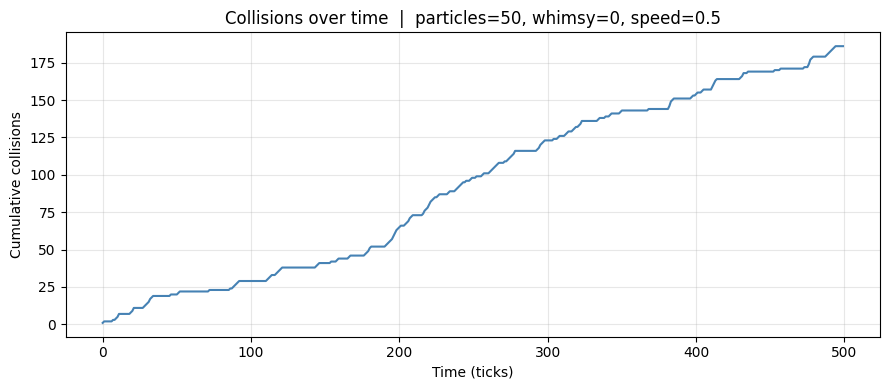

In [5]:
plt.figure(figsize=(9, 4))

# Plot the collision history list — one value per tick
plt.plot(model.collision_history, color='steelblue', linewidth=1.5)

# Labels and formatting
plt.xlabel('Time (ticks)')
plt.ylabel('Cumulative collisions')
plt.title(f'Collisions over time  |  particles={NUM_PARTICLES}, whimsy={WHIMSY}, speed={SPEED}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6 — Visualize agent positions

Let's see where all the particles are at the end of the simulation. Each dot is one particle, and the arrow shows the direction it is currently heading.

To draw the arrows, we do the same trig as in `move()`: convert heading to radians, then use `sin` and `cos` to get the x and y components of the arrow direction.


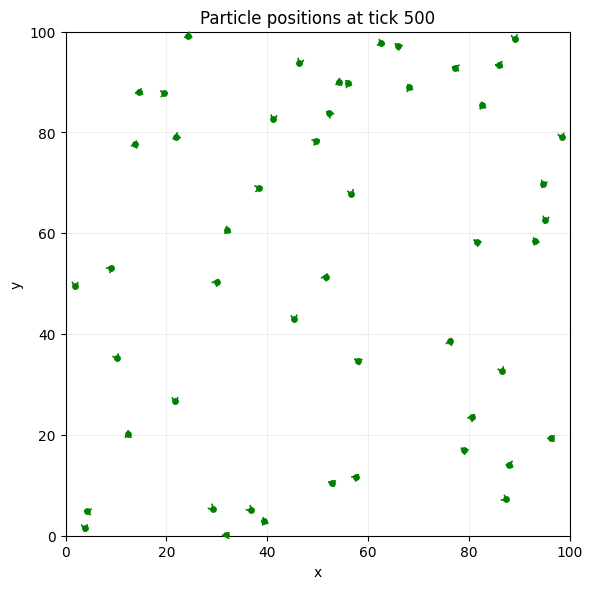

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

# Collect all x and y positions into separate lists for scatter plot
xs = [p.x for p in model.particles]   # list comprehension: get .x from every particle
ys = [p.y for p in model.particles]   # same for .y

# Draw each particle as an arrow showing its heading direction
for p in model.particles:
    # LOCAL variables — only exist inside this loop iteration
    angle = math.radians(p.heading)      # convert this particle's heading to radians
    dx = 0.8 * math.sin(angle)           # x component of the arrow
    dy = 0.8 * math.cos(angle)           # y component of the arrow

    # Draw an arrow from the particle's position pointing in its heading direction
    ax.annotate('', xy=(p.x + dx, p.y + dy), xytext=(p.x, p.y),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.2))

# Draw a dot at each particle's position
ax.scatter(xs, ys, color='green', s=15, zorder=5)

# Set the axis limits to match the world size
ax.set_xlim(0, WORLD_SIZE)
ax.set_ylim(0, WORLD_SIZE)
ax.set_aspect('equal')   # make sure the world looks square, not stretched
ax.set_title(f'Particle positions at tick {model.tick}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## Step 7 — Compare conditions

One of the most powerful things about ABMs is that you can run the same model with different parameters and compare the results systematically. This is how we go from "playing with a simulation" to actually doing science.

Here we run four conditions and plot them together:
- Few particles vs many particles
- Low whimsy (straight-line movement) vs high whimsy (random walk)

**Think about this before running:** Which condition do you predict will have the most collisions? Fewest? Does more randomness help or hurt collision rates?

## Interpreting the result

**The big picture: particle density matters way more than whimsy**

The most striking thing is that the two blue lines (50 particles) are basically flat at the bottom, while the two red lines (200 particles) shoot up steeply. Going from 50 to 200 particles (4x more) didn't just quadruple collisions. It produced roughly 20x more collisions. That's a non-linear relationship, and it's one of the most important findings from this model.

**Why non-linear?** 

Because collisions depend on pairs of particles. With 50 particles there are 1,225 possible pairs. With 200 particles there are 19,900 possible pairs. The number of pairs grows much faster than the number of particles—so collisions explode.

**The whimsical finding—the surprising one**
Look closely at the two red lines. The straight-line movers (whimsy=0, darker red) actually collide slightly more than the random walkers (whimsy=180, lighter red). Same with the blue lines.

This is counterintuitive at first. You might expect more randomness = more chaotic = more collisions. But think about it:

- A particle moving in a straight line efficiently covers new ground. It sweeps through space and is likely to encounter particles it hasn't met yet.
- A particle doing a random walk tends to wander around the same area, retracing its path. It's less efficient at exploring space, so it encounters fewer new particles.

This connects to a real concept in ecology and social science called search efficiency"—straight-line movement is a better search strategy when you're looking for encounters.


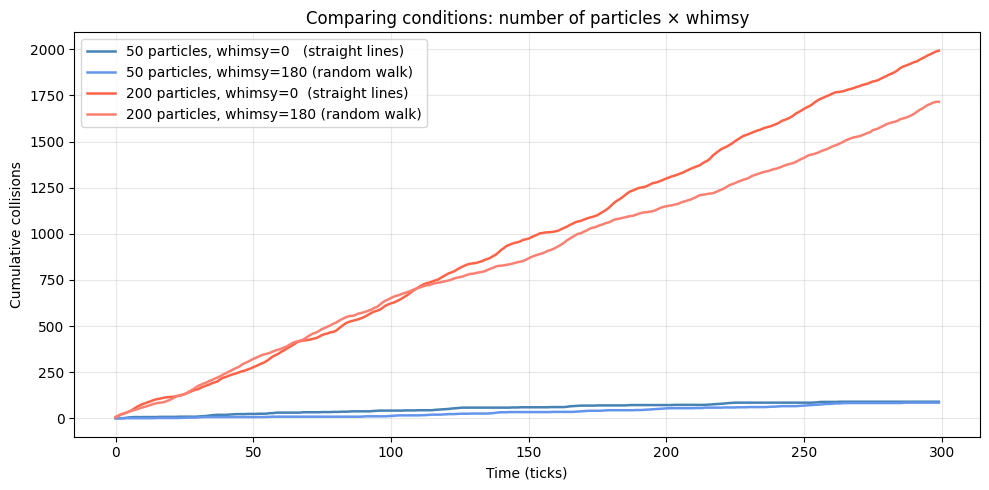

In [7]:
# Define the four conditions we want to compare
# Each condition is a dictionary — a collection of named values
conditions = [
    {'num_particles': 50,  'whimsy': 0,   'label': '50 particles, whimsy=0   (straight lines)'},
    {'num_particles': 50,  'whimsy': 180, 'label': '50 particles, whimsy=180 (random walk)'},
    {'num_particles': 200, 'whimsy': 0,   'label': '200 particles, whimsy=0  (straight lines)'},
    {'num_particles': 200, 'whimsy': 180, 'label': '200 particles, whimsy=180 (random walk)'},
]

TICKS  = 300
colors = ['steelblue', 'cornflowerblue', 'tomato', 'salmon']

plt.figure(figsize=(10, 5))

# Run one simulation per condition and plot the results
# zip() lets us loop over two lists at the same time
for cond, color in zip(conditions, colors):
    # Create a fresh model for this condition
    m = ParticleModel(
        num_particles = cond['num_particles'],
        whimsy        = cond['whimsy'],
        speed         = 0.5,
        world_size    = 100,
        collision_radius = 1.0
    )
    m.run(ticks=TICKS)   # run it

    # Plot this condition's collision history
    plt.plot(m.collision_history, label=cond['label'], color=color, linewidth=1.8)

plt.xlabel('Time (ticks)')
plt.ylabel('Cumulative collisions')
plt.title('Comparing conditions: number of particles × whimsy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary & Key Takeaways

### What you built:
A complete agent-based model from scratch. Agents with individual state, a world with global rules, movement, collision detection, and visualization.

### Core concepts from this model:

| Concept | What it means in this model |
|---|---|
| **Class** | A blueprint for creating objects. `Particle` is the agent blueprint, `ParticleModel` is the world blueprint |
| **`__init__`** | The constructor — runs when an object is created, sets its starting values |
| **`self`** | Refers to this specific object — gives each agent its own private copy of its data |
| **Global variables** | Belong to the whole model — `collisions`, `tick`, `speed`, `whimsy` |
| **Agent variables** | Belong to one particle — `self.x`, `self.y`, `self.heading` |
| **Local variables** | Temporary, exist only inside a function — `angle`, `dx`, `dist` |
| **Random walk** | Each step, agents randomly wobble their heading then move forward |
| **Toroidal world** | Edges wrap around using the `%` (modulo) operator |
| **Collision detection** | Measure distance between every pair of agents each tick |
| **Emergence** | The collision rate pattern emerges from simple individual rules — nobody programmed it directly |

---

### Experiment ideas:
- Does collision rate scale linearly with number of particles, or faster?
- At `whimsy=0`, particles move in straight lines — do they collide more or less than at `whimsy=180`? Why might that be?
- What happens when `speed` is very large relative to `world_size`?
- What if you make `collision_radius` much larger — say 5.0?
